# Clustering Colors

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/IBM_Introduction_to_Machine_Learning_Specialization/portfolio-6.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Use K-means clustering to group similar colors in an image.

[K-means clustering](https://en.wikipedia.org/wiki/K-means_clustering) groups an unlabeled dataset into different clusters, where K defines the number of pre-defined clusters that need to be created in the process. The algorithm works iteratively to assign data points to the nearest cluster centroids and optimize the centroids’ positions. The main objective of the K-means algorithm is to minimize the sum of distances between the points and their respective cluster centroid.

## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

sns.set_style("whitegrid")

## Load the image

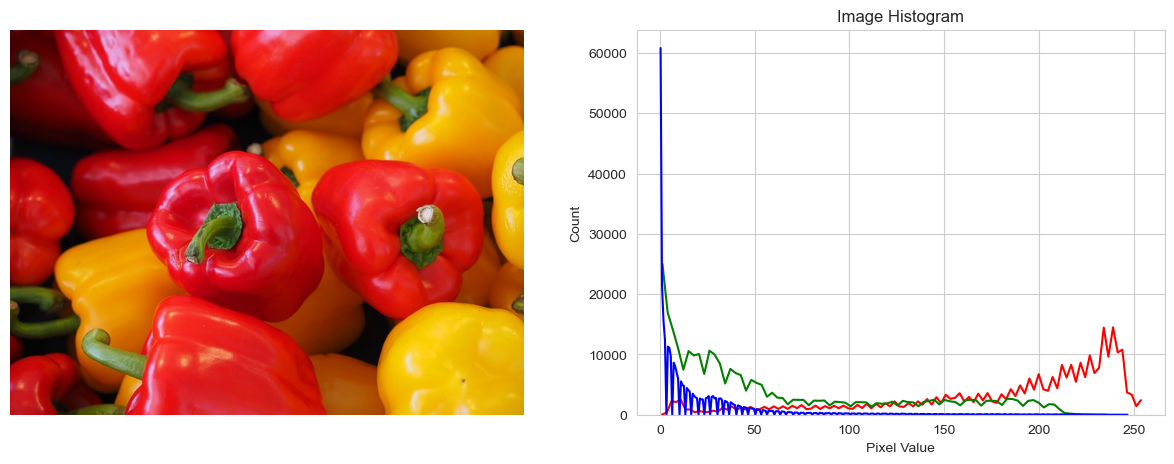

In [ ]:
image_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%201/images/peppers.jpg"
response = requests.get(image_url)
image = np.array(Image.open(BytesIO(response.content)))

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].imshow(image)
axs[0].axis('off')

sns.histplot(image[:, :, 0].ravel(), color='red', element="poly", fill=False, ax=axs[1])
sns.histplot(image[:, :, 1].ravel(), color='green', element="poly", fill=False, ax=axs[1])
sns.histplot(image[:, :, 2].ravel(), color='blue', element="poly", fill=False, ax=axs[1])
axs[1].set_title('Image Histogram')
axs[1].set_xlabel('Pixel Value')

plt.show()

## Compute K-means clustering and evaluate the quality of clusters

In [3]:
def cluster_image(original_image, n_clusters):
    original_flat_image = original_image.reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(original_flat_image)
    clustered_flat_image = original_flat_image.copy()

    # Loop for each cluster center
    for label in np.unique(kmeans.labels_):
        clustered_flat_image[kmeans.labels_ == label, :] = kmeans.cluster_centers_[label]

    clustered_image = clustered_flat_image.reshape(original_image.shape)
    
    return clustered_image, kmeans.inertia_

def get_silhouette_score(original_image, n_clusters):
    original_flat_image = np.resize(original_image, (120, 160, 3)).reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(original_flat_image)
    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_average = silhouette_score(original_flat_image, kmeans.labels_)
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(original_flat_image, kmeans.labels_)

    return silhouette_average, sample_silhouette_values, kmeans.labels_

**Inertia** in K-means clustering refers to the sum of squared distances of each data point to its closest cluster center, also known as the within-cluster sum-of-squares. It measures the compactness of clusters, with lower inertia values indicating better clustering as the data points within the clusters are more similar to each other. Inertia is used to evaluate the quality of the clustering and is minimized during the K-means algorithm to achieve optimal cluster formation.

The [silhouette](https://en.wikipedia.org/wiki/Silhouette_(clustering)) score is a metric used to evaluate the quality of clusters created by clustering algorithms, such as K-means. It measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The silhouette score ranges from -1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. The silhouette score is calculated for each data point, and the average of these scores provides an overall measure of the clustering quality. A higher average silhouette score indicates better clustering results.

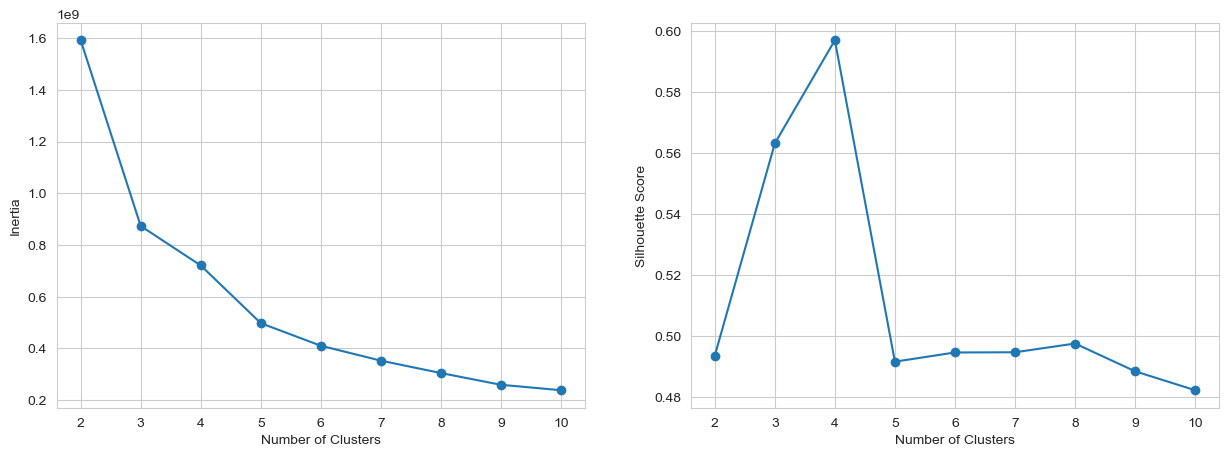

In [4]:
n_clusters = range(2, 11)
clustered_images = []
inertias = []
silhouette_scores = []
silhouette_values = []
cluster_labels = []

for n in n_clusters:
    clustered_image, inertia = cluster_image(image, n)
    clustered_images.append(clustered_image)
    inertias.append(inertia)
    silhouette_average, sample_silhouette_values, cluster_label = get_silhouette_score(image, n)
    silhouette_scores.append(silhouette_average)
    silhouette_values.append(sample_silhouette_values)
    cluster_labels.append(cluster_label)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(n_clusters, inertias, marker='o')
axs[0].set_xlabel('Number of Clusters')
axs[0].set_ylabel('Inertia')

axs[1].plot(n_clusters, silhouette_scores, marker='o')
axs[1].set_xlabel('Number of Clusters')
axs[1].set_ylabel('Silhouette Score')

plt.show()

A silhouette plot is a graphical tool used to evaluate the quality of clustering. It provides a visual representation of how well each data point fits into its assigned cluster, considering both the cohesion within the cluster and the separation from other clusters. The plot displays the silhouette values for each data point, which range from -1 to 1. A silhouette value close to 1 indicates that the data point is well-matched to its cluster and far from neighboring clusters, while a value close to 0 suggests that the point is on the border between two clusters. A negative value implies that the point may have been assigned to the wrong cluster. Additionally, the silhouette plot can highlight outliers or poorly clustered data points, allowing for further analysis and refinement of the clustering process.

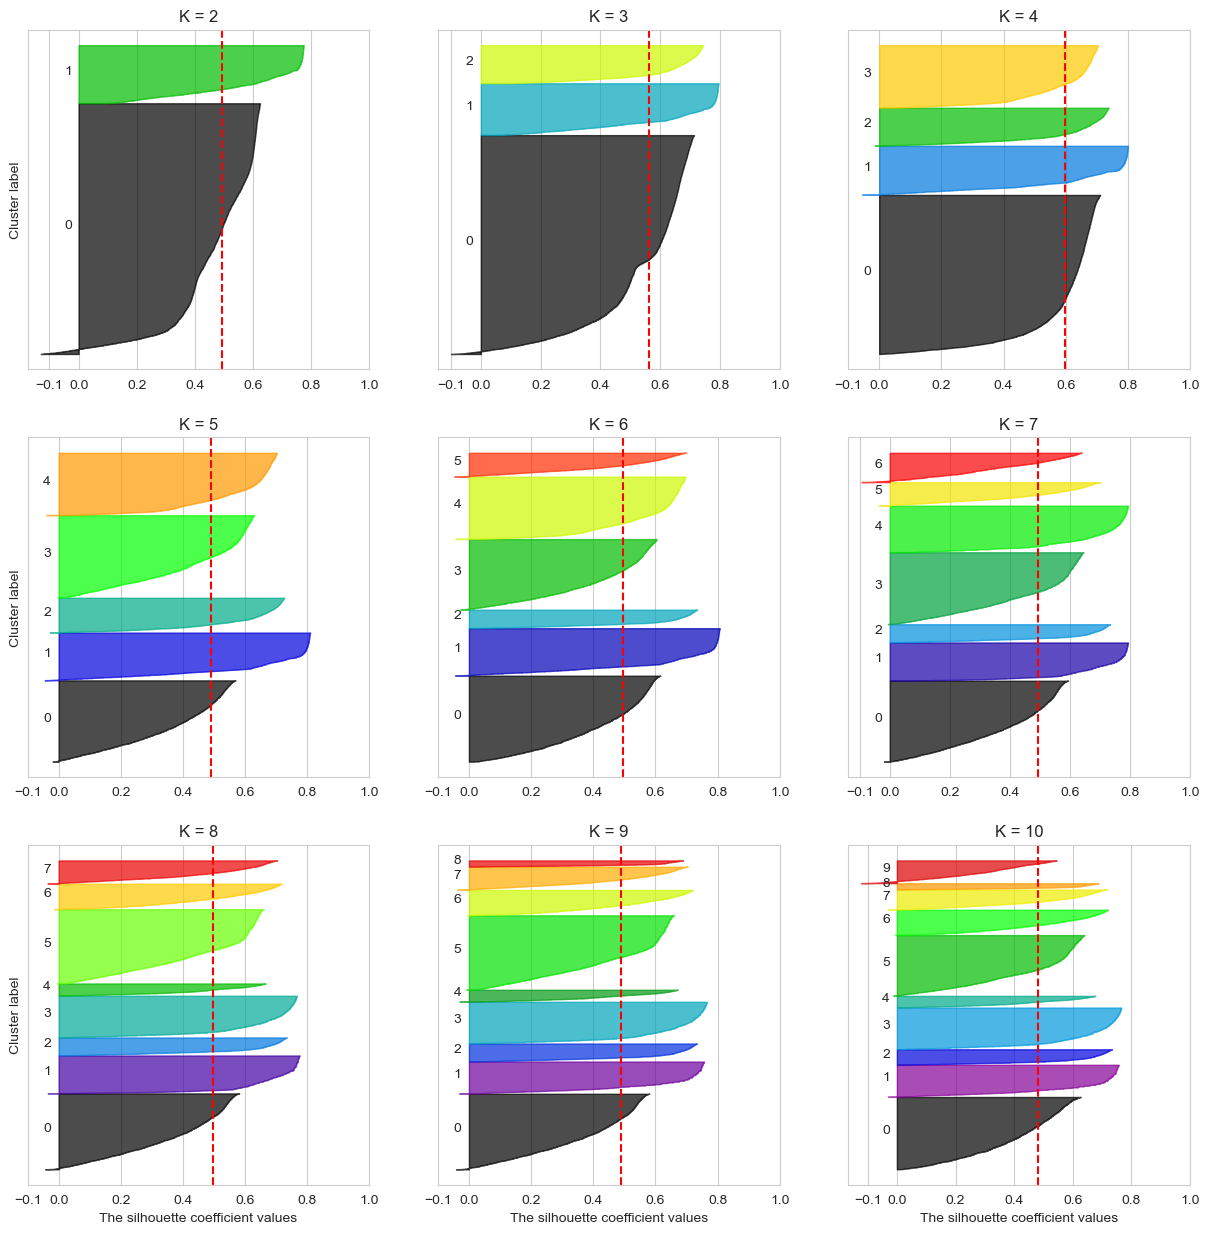

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
y_lower = 10

for j, ax in enumerate(axs.flatten()):
    for i in range(n_clusters[j]):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = silhouette_values[j][cluster_labels[j] == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters[j])
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, 
                         facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title(f"K = {n_clusters[j]}")

    if j in [6, 7, 8]:
        ax.set_xlabel("The silhouette coefficient values")
    
    if j in [0, 3, 6]:  
        ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_scores[j], color="red", linestyle="--")
    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.show()

## Visualize the clustered image using the optimal number of clusters

Based on the inertia and silhouette plots, the optimal number of clusters for this image is between 4 and 5.

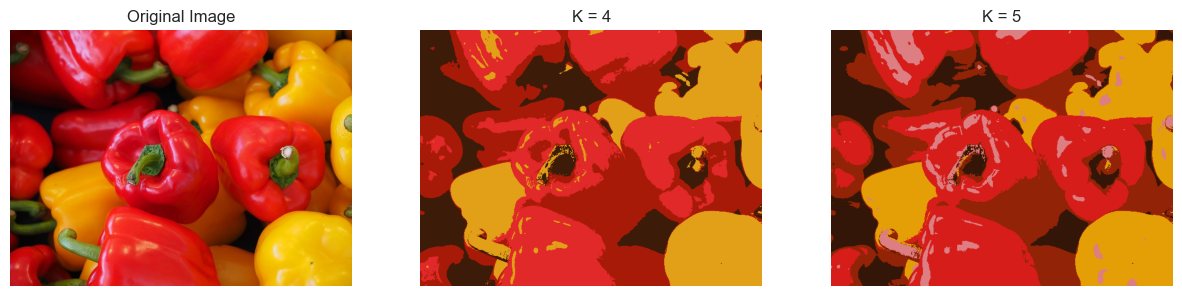

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(image)
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(clustered_images[2])
axs[1].set_title("K = 4")
axs[1].axis('off')

axs[2].imshow(clustered_images[3])
axs[2].set_title("K = 5")
axs[2].axis('off')

plt.show()